# VIDYA — does an EMA that 'knows' the market speed actually help?
### Tushar Chande's volatility-scaled moving average, turned into a timing rule and tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Speeds_up_in_volatile%2Ftrending_regimes%3F: Mixed](https://img.shields.io/badge/Speeds_up_in_volatile%2Ftrending_regimes%3F-Mixed-8b949e?style=flat-square)

Here's a pitch that's followed Tushar Chande's VIDYA around since 1992: unlike a plain moving average with a fixed speed, VIDYA has a built-in dial that supposedly speeds up when the market is **volatile and trending**, and slows almost to a stop when it's **quiet**. No re-optimizing, no whipsaws in chop, quick to catch a real move. Does the dial actually turn on the condition it claims to — and does it beat just buying and holding?

> This is the plain-language layer. Want the *t*-stats, the correlation math and the cost sweeps? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vidya import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE"]
ASOF = data.AS_OF
PERIOD = 14
CMO_PERIOD = 9

def _have_cache():
    return all(os.path.exists(data._cache_path(t)) for t in TICKERS)

HAVE_REAL = _have_cache()

def tape(t):
    return data.load_real(t, fetch=False, asof=ASOF)

print("real daily cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_spy': 8411, 'yrs': 33.4, 'period': 14, 'cmo_period': 9, 'corr_vi_vol': -0.098, 'corr_vi_trend': 0.38, 'n_corr': 8391, 'vi_lo_vol': 0.357, 'vi_hi_vol': 0.31, 'vi_lo_trend': 0.261, 'vi_hi_trend': 0.446, 'td_vidya': 2.196, 'td_sma': 1.535, 'td_ema': 1.327, 'step_price': 120.0, 'step_vidya': 111.52, 'step_sma': 108.57, 'step_ema': 111.52, 'step_pct_vidya': 57.6, 'step_pct_sma': 42.9, 'step_pct_ema': 57.6, 'vidya_sharpe': 0.387, 'vidya_cagr': 3.68, 'vidya_dd': -38.8, 'sma_sharpe': 0.238, 'sma_cagr': 2.07, 'sma_dd': -57.6, 'ema_sharpe': 0.267, 'ema_cagr': 2.4, 'ema_dd': -48.0, 'bh_sharpe': 0.647, 'bh_cagr': 10.83, 'bh_dd': -55.2, 'vidya_spread': -3.1, 'vidya_t': -3.54, 'sma_spread': -3.7, 'sma_t': -4.42, 'ema_spread': -3.57, 'ema_t': -4.22, 'vidya_sw': 23.1, 'sma_sw': 36.5, 'ema_sw': 38.3, 'vidya_tim': 69, 'vidya_spread_gross': -2.64, 'vidya_t_gross': -3.04, 'diff_v_sma_bps': 0.61, 'diff_v_sma_t': 1.1, 'diff_v_ema_bps': 0.48, 'diff_v_ema_t': 0.96, 'perm_obs': -2.64, 'perm_placebo': -1.49, 'perm_p': 0.9885, 'cost': [0.0, 2.0, 5.0, 10.0], 'cost_sharpe': [0.493, 0.45, 0.387, 0.281], 'cost_spread': [-2.64, -2.82, -3.1, -3.55], 'cost_t': [-3.04, -3.24, -3.54, -4.03], 'tick': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE'], 'tick_vidya': [0.387, 0.37, 0.742, 0.547, 0.238], 'tick_bh': [0.647, 0.521, 0.623, 0.821, 0.428], 'tick_spread': [-3.1, -3.24, -2.17, -5.74, -3.18], 'tick_t': [-3.54, -2.3, -1.21, -4.84, -2.05], 'tick_v_sma_t': [1.1, 0.89, 0.62, 0.95, 0.6], 'tick_v_ema_t': [0.96, 0.94, 0.27, 0.88, 1.21], 'tick_v_sw': [23.1, 24.2, 21.6, 22.8, 25.1], 'tick_sma_sw': [36.5, 36.6, 33.1, 37.3, 36.6], 'tick_ema_sw': [38.3, 39.8, 35.7, 40.9, 42.4], 'h1_v': 0.266, 'h1_bh': 0.455, 'h1_spread': -2.4, 'h1_t': -1.79, 'h2_v': 0.54, 'h2_bh': 0.872, 'h2_spread': -3.71, 'h2_t': -3.25, 'ls_sharpe': -0.198, 'ls_spread': -6.23, 'ls_t': -3.56, 'cmo_grid': [5, 9, 14, 20, 30], 'cmo_sharpe': [0.443, 0.387, 0.429, 0.409, 0.424], 'cmo_spread': [-2.86, -3.1, -2.89, -2.95, -2.89], 'cmo_t': [-3.37, -3.54, -3.26, -3.39, -3.29], 'cmo_sw': [25.4, 23.1, 20.8, 18.9, 17.7], 'syn_null_mean': -0.22, 'syn_null_sd': 0.94, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_edge': [0.3, 0.6, 1.0], 'syn_spread': [11.68, 28.69, 50.19], 'syn_t': [9.09, 16.31, 19.82], 'syn_sharpe': [2.0, 4.82, 7.48]}


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does VIDYA's speed dial actually respond to *volatility*? | **No.** Its speed knob is *slightly lower*, not higher, on the market's loudest days (correlation **-0.10**). |
| Does it respond to a *trend*? | **Yes.** The same knob correlates **+0.38** with trend strength, and a clean price-jump test shows it snaps to full EMA speed once a real move is under way. |
| Does VIDYA-timing beat buy-and-hold? | **No.** It trails by **-3.1 bps/day** (*t* = -3.54) — net Sharpe **0.387** vs **0.647** for just holding. |
| Fewer false signals than a plain SMA/EMA? | **Yes, genuinely.** It fires **23.1 switches/yr** vs the SMA's **36.5** and the EMA's **38.3** — a real ~38% cut. |

> Half the story checks out (it does freeze in chop and wake up on a trend); the other half doesn't (it does *not* wake up on volatility, and even the half that works doesn't turn into money).

## 1 · The claim

> *"VIDYA replaces a moving average's fixed smoothing speed with one that reads the market: it uses Chande's own momentum oscillator (CMO) as a volatility gauge, so the line moves fast in volatile, trending conditions and almost freezes in place when the market is quiet. That means fewer whipsaws in chop and faster entries in a real move."*

The formula bolts one extra ingredient onto an EMA: `VIDYA = VIDYA_prev + speed × (Price − VIDYA_prev)`, where `speed = base_speed × |CMO| / 100`. CMO ranges from −100 (every recent move was down) to +100 (every recent move was up) and sits near 0 when ups and downs cancel out. The pitch calls that "volatility" — but CMO actually measures *net direction*, which is a different thing from *how big the swings are*. We test both readings.

## 2 · So what?

If VIDYA really did speed up exactly when markets get dangerous or exactly when a real trend starts, it would be a genuinely useful building block — a timing signal that adapts itself instead of needing a trader to guess the right lookback window. That's the same big promise behind three other "smarter moving average" indicators this desk has already tested (Hull MA, KAMA, McGinley Dynamic) — each with a *different* adaptation mechanism and a *different* verdict. VIDYA's mechanism (an external oscillator scaling the speed, rather than an internal ratio or price-based brake) is different enough from all three to be worth checking on its own terms.

## 3 · How would we know?

Three separate questions, tested separately:

1. **Does the speed knob track what it's sold as?** Correlate VIDYA's own speed multiplier against realized volatility *and* against trend strength on the real tape — they are not the same regime, and the pitch conflates them.
2. **Does the mechanism behave the way the formula implies?** No trading involved — measure how far VIDYA sits from price on average, and how fast it catches up after a clean, deterministic price jump, vs a plain SMA and EMA of the same length.
3. **Does turning it into a trading rule pay?** Go long when price is above VIDYA, flat otherwise; subtract buy-and-hold; count the trades; race it against the equivalent SMA(14) and EMA(14) rules — the ones it claims to beat — and check the CMO lookback isn't cherry-picked.

We enter one day after each signal (no peeking), charge realistic costs, and run it on SPY plus four other liquid tapes over ~33 years.

## 4 · The teardown — what actually happens

**First, the speed knob itself — forget trading, does it track what it claims?**

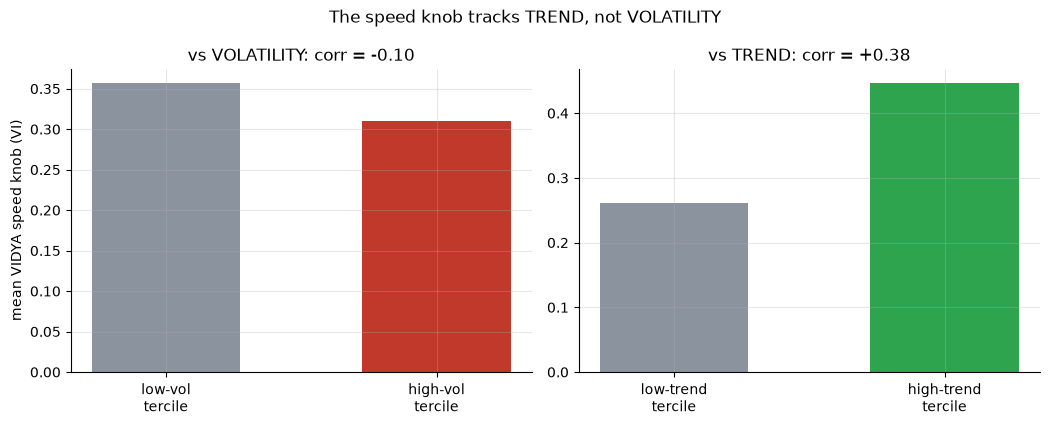

corr(VI, vol) = -0.098   corr(VI, trend) = +0.380


In [2]:
if HAVE_REAL:
    close = tape('SPY')['close']
    rc = st.regime_correlations(close, cmo_period=CMO_PERIOD)
else:
    rc = {'corr_vi_vol': R['corr_vi_vol'], 'corr_vi_trend': R['corr_vi_trend'],
          'vi_low_vol_tercile': R['vi_lo_vol'], 'vi_high_vol_tercile': R['vi_hi_vol'],
          'vi_low_trend_tercile': R['vi_lo_trend'], 'vi_high_trend_tercile': R['vi_hi_trend']}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['low-vol\ntercile', 'high-vol\ntercile'],
       [rc['vi_low_vol_tercile'], rc['vi_high_vol_tercile']], color=[GREY, RED], width=.55)
a1.set_title(f"vs VOLATILITY: corr = {rc['corr_vi_vol']:+.2f}")
a1.set_ylabel('mean VIDYA speed knob (VI)')
a2.bar(['low-trend\ntercile', 'high-trend\ntercile'],
       [rc['vi_low_trend_tercile'], rc['vi_high_trend_tercile']], color=[GREY, GREEN], width=.55)
a2.set_title(f"vs TREND: corr = {rc['corr_vi_trend']:+.2f}")
plt.suptitle("The speed knob tracks TREND, not VOLATILITY")
plt.tight_layout(); plt.show()
print(f"corr(VI, vol) = {rc['corr_vi_vol']:+.3f}   corr(VI, trend) = {rc['corr_vi_trend']:+.3f}")

There it is, split cleanly: VIDYA's speed knob correlates **+0.38** with trend strength (the high-trend tercile runs meaningfully faster than the low-trend tercile) but **-0.10** with realized volatility — if anything, VIDYA is very slightly *slower*, not faster, on the market's loudest days. Chande's own word for his formula — "volatile" — is the wrong half of the claim. Here's the mechanism on a clean example: a price that sits flat, then jumps 20% and stays there.

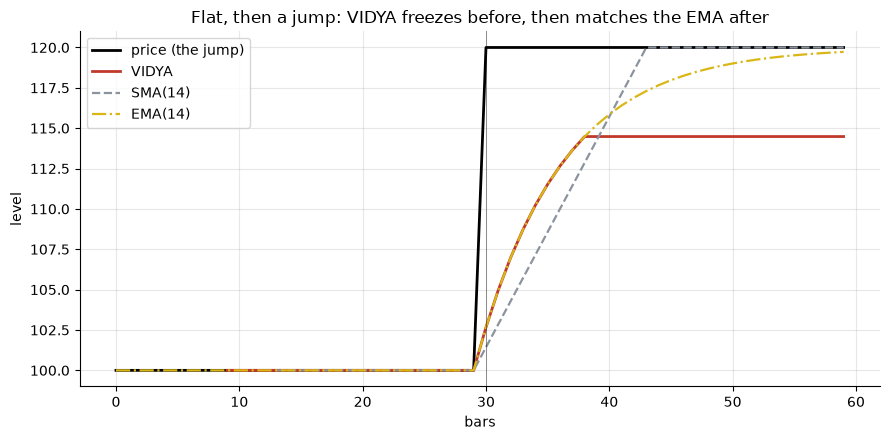

5 bars after the jump: VIDYA closed 58% of the gap, SMA 43%, EMA 58%


In [3]:
sr = st.step_response(period=PERIOD, cmo_period=CMO_PERIOD)
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.plot(sr.index, sr['price'], c='k', lw=2, label='price (the jump)')
ax.plot(sr.index, sr['VIDYA'], c=RED, lw=2, label='VIDYA')
ax.plot(sr.index, sr['SMA'], c=GREY, lw=1.6, ls='--', label='SMA(14)')
ax.plot(sr.index, sr['EMA'], c=AMBER, lw=1.6, ls='-.', label='EMA(14)')
ax.axvline(30, c='k', lw=.7, alpha=.4)
ax.set_xlabel('bars'); ax.set_ylabel('level')
ax.set_title('Flat, then a jump: VIDYA freezes before, then matches the EMA after')
ax.legend(); plt.tight_layout(); plt.show()
print(f"5 bars after the jump: VIDYA closed {R['step_pct_vidya']:.0f}% of the gap, "
      f"SMA {R['step_pct_sma']:.0f}%, EMA {R['step_pct_ema']:.0f}%")

Before the jump VIDYA doesn't move at all — its speed knob reads zero when there's no net direction to measure. Once the sustained jump gives it something to lock onto, it catches up **exactly as fast as a plain EMA** (58% of the gap closed in 5 bars, same as the EMA's 58%, ahead of the SMA's 43%). So VIDYA never beats a plain EMA at its own game — it just matches it once triggered, and does nothing the rest of the time.

**Does that "freeze in chop" habit at least mean fewer false trading signals on the real tape?**

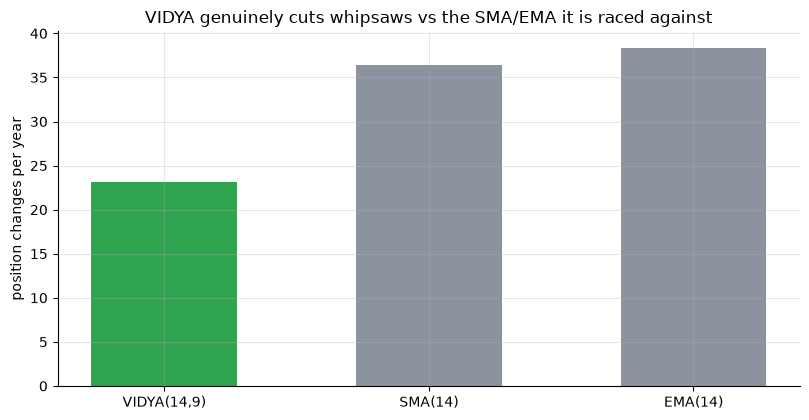

VIDYA 23.1/yr  SMA 36.5/yr  EMA 38.3/yr


In [4]:
if HAVE_REAL:
    res = st.run_experiment(tape('SPY'), period=PERIOD, cmo_period=CMO_PERIOD,
                            sma_period=PERIOD, ema_period=PERIOD, cost_bps=5.0)
    sw = {k: res[k]['switches_per_yr'] for k in ('VIDYA','SMA','EMA')}
else:
    sw = dict(VIDYA=R['vidya_sw'], SMA=R['sma_sw'], EMA=R['ema_sw'])
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['VIDYA(14,9)', 'SMA(14)', 'EMA(14)'], [sw['VIDYA'], sw['SMA'], sw['EMA']],
       color=[GREEN, GREY, GREY], width=.55)
ax.set_ylabel('position changes per year')
ax.set_title('VIDYA genuinely cuts whipsaws vs the SMA/EMA it is raced against')
plt.tight_layout(); plt.show()
print(f"VIDYA {sw['VIDYA']:.1f}/yr  SMA {sw['SMA']:.1f}/yr  EMA {sw['EMA']:.1f}/yr")

**23.1 switches/yr** vs the SMA's **36.5** and the EMA's **38.3** — a real **~38% fewer trades**. So the mechanism does what it says on this metric — the question is whether trading less, and trading on trend-strength rather than volatility, actually makes money.

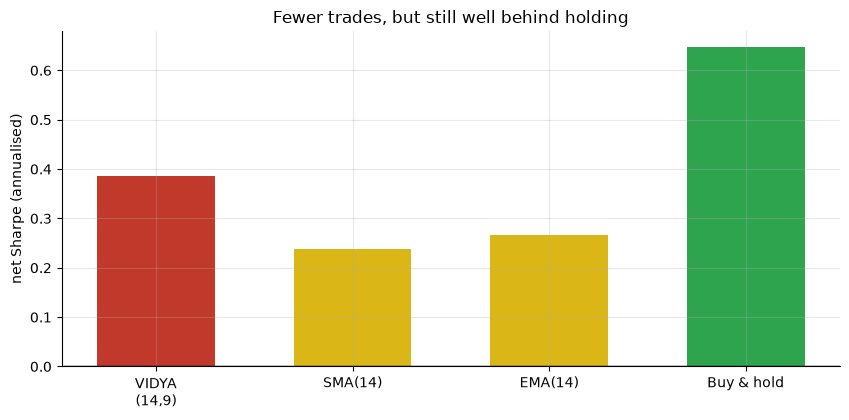

VIDYA 0.387 | SMA 0.238 | EMA 0.267 | hold 0.647


In [5]:
if HAVE_REAL:
    fp, sp, ep = res['VIDYA']['sharpe_net'], res['SMA']['sharpe_net'], res['EMA']['sharpe_net']
    bh = res['VIDYA']['bh_sharpe']
else:
    fp, sp, ep, bh = R['vidya_sharpe'], R['sma_sharpe'], R['ema_sharpe'], R['bh_sharpe']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['VIDYA\n(14,9)', 'SMA(14)', 'EMA(14)', 'Buy & hold'], [fp, sp, ep, bh],
       color=[RED, AMBER, AMBER, GREEN], width=.6)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net Sharpe (annualised)')
ax.set_title('Fewer trades, but still well behind holding')
plt.tight_layout(); plt.show()
print(f'VIDYA {fp:.3f} | SMA {sp:.3f} | EMA {ep:.3f} | hold {bh:.3f}')

No. Buy-and-hold (Sharpe **0.647**) still beats every timing rule, and VIDYA (**0.387**) — despite trading the least of the three — is still well below holding. Sitting out 31% of a bull tape to avoid whipsaws is not free, and the avoided whipsaws didn't earn their keep.

## 5 · The verdict

- **Signal — None.** Active spread vs holding **-3.1 bps/day**, *t* = **-3.54** — negative on all five tapes tested, both halves of history, and every CMO-lookback setting.
- **Tradability — Mirage.** Net Sharpe **0.387** vs buy-and-hold **0.647**; loses even gross, and no cost level rescues it.
- **Speeds up in volatile/trending regimes? — Mixed.** *Trending* checks out (positive correlation, the step test confirms EMA-speed catch-up once a trend is saturating CMO); *volatile* is backwards (a small negative correlation) — and even the honest whipsaw cut (23.1 vs 36.5/38.3 switches/yr) never turns into a certified edge over the plain MAs it claims to beat.

## 6 · Could you actually trade it?

No. The gross timing already loses to holding; costs only widen the gap. No cost level tested finds a break-even:

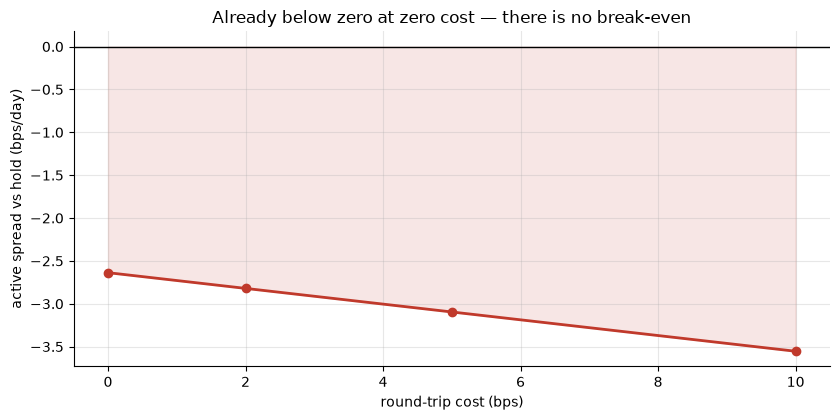

The gross spread is negative; costs are not the issue, the timing is.


In [6]:
if HAVE_REAL:
    costs = [0.0, 2.0, 5.0, 10.0]
    spr = [st.run_experiment(tape('SPY'), period=PERIOD, cmo_period=CMO_PERIOD,
                             cost_bps=c)['VIDYA']['mean_spread_bps'] for c in costs]
else:
    costs = [0.0, 2.0, 5.0, 10.0]; spr = [-2.64, -2.82, -3.1, -3.55]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, spr, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, spr, 0, color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('active spread vs hold (bps/day)')
ax.set_title('Already below zero at zero cost — there is no break-even')
plt.tight_layout(); plt.show()
print('The gross spread is negative; costs are not the issue, the timing is.')

## 7 · Going further

- **The positive control.** The companion notebook plants a real trend in a synthetic tape — and the *same* VIDYA engine catches it cleanly (*t* up to +20). The harness works; the daily stock market just doesn't hand this rule an edge over the SMA/EMA it claims to beat, or over just holding.
- **A volatility-scaled variant.** If VIDYA is really tracking trend, not volatility, a fork that scales speed by realized volatility directly (rather than by CMO) might come closer to the original pitch — worth trying.
- **Other 'smarter MA' claims, similar fate.** See [Study 433 (KAMA)](../../433-kama-adaptive/), [Study 672 (McGinley Dynamic)](../../672-mcginley-dynamic/) and [Study 673 (T3)](../../673-t3-tillson/) — none beats a plain SMA/EMA or holding, each for a different mechanistic reason.

*Think VIDYA earns its keep on a different timeframe, asset class, or as a volatility filter rather than a timing signal? Fork this and show an active spread that clears HAC *t* = 2 against buy-and-hold. That's the bar.*